In [20]:
# Secion 0: Imports

import os
import gc, math, multiprocessing
from pathlib import Path
from collections import defaultdict
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
import pyarrow as pa
import pyarrow.parquet as pq
import heapq
import matplotlib.pyplot as plt
import json
import seaborn as sns
import matplotlib.colors as mcolors
from math import floor, ceil

from itertools import product
from IPython.display import display
from IPython.display import clear_output
from matplotlib.ticker import MultipleLocator

tqdm.monitor_interval = 0

In [10]:
import matplotlib as mpl
import shutil
import os

# 1. Get and Clear the cache directory
cache_dir = mpl.get_cachedir()
print(f"Matplotlib cache dir: {cache_dir}")

if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)
    print("✅ Cache directory deleted.")
else:
    print("ℹ️ Cache directory already gone.")

# 2. Trigger a refresh (This replaces the old _rebuild() method)
# Accessing the FontManager object will now trigger an auto-rebuild internally
fm = mpl.font_manager.FontManager()
print("✅ Font Manager initialized (cache will rebuild on next plot).")
print("🚀 Now RESTART your kernel/notebook.")

Matplotlib cache dir: C:\Users\Owner\.matplotlib
✅ Cache directory deleted.
✅ Font Manager initialized (cache will rebuild on next plot).
🚀 Now RESTART your kernel/notebook.


In [3]:
import matplotlib as mpl
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Liberation Sans', 'Arial', 'Sans-Serif']
# optionally change backend if headless
# mpl.use('Agg')   # uncomment only if you want non-interactive backend (no GUI)

In [2]:
# Section 1: Config

RUN_BASE_DIR = Path(r"C:/Users/Owner/Backtest_results/BTC/Opt_Session_20260302_185231_01")  
MASTER_NAME = "master_results.parquet"
MASTER_PATH = RUN_BASE_DIR / MASTER_NAME
EPS = 1e-12

# reorder cols_needed to match master column order and avoid unnecessary IO
cols_needed = [
    "score", "SL", "TP", "win_pos", "total_pos",
    "side", "exit_window_h", "era_int",
    "ma_int", "entry_lookback_h"
]

In [7]:
# Section 2: Memory-Safe Streaming Aggregation & Era Partitioning

def ma_int_to_combo(ma_int):
    try:
        return format(int(ma_int) & 0x0F, "04b")
    except Exception:
        return "0000"


def _read_parquet_row_group(path, rg_idx, cols=None):
    pf = pq.ParquetFile(str(path))
    tbl = pf.read_row_group(rg_idx, columns=cols)
    return tbl.to_pandas()


# small helpers for summary save/load
def _safe_write_parquet(df: pd.DataFrame, path: Path):
    try:
        # reset index so the parquet file is simple to reload later
        if isinstance(df, pd.DataFrame):
            if not df.empty:
                df_to_write = df.reset_index()
            else:
                df_to_write = pd.DataFrame(columns=df.columns)
            df_to_write.to_parquet(str(path), index=False)
        else:
            raise TypeError("Expected pandas DataFrame to write.")
    except Exception as e:
        # fallback: try writing with index (handles odd multiindex cases)
        try:
            df.to_parquet(str(path))
        except Exception as e2:
            print(f"Failed to write parquet {path}: {e2}")


def _safe_read_parquet(path: Path) -> pd.DataFrame:
    try:
        return pd.read_parquet(str(path))
    except Exception as e:
        raise RuntimeError(f"Failed to read parquet {path}: {e}")


def stream_aggregate_singlethread(
    base_dir: Path,
    master_parquet: Path = None,
    sl_tp_range=(200,800,500,15000),
    sltp_min_rows=20,
    parquet_use_pyarrow=True,
    merge_batch_size=200,
    gc_every=200,
    verbose=True,
    timeframe: tuple = None,
    era_months: int = None,
    force_rebuild: bool = False
):
    """
    Streaming aggregation that:
    - loads pre-saved summaries when present (unless force_rebuild=True)
    - streams parquet row-groups otherwise and aggregates into summaries

    Minimal / performance-minded variant:
    - no config JSON loader
    - no bitwise re-calculation (ma_int is authoritative)
    - no dtype reassigns or manual renames
    - time logic uses era_int directly
    """
    base_dir = Path(base_dir)
    results_dir = base_dir / "results"

    # summary paths (saved inside base_dir)
    ma_path = base_dir / "ma_summary.parquet"
    lb_path = base_dir / "lb_ma_summary.parquet"
    sltp_path = base_dir / "sltp_summary.parquet"
    era_dir = base_dir / "era_summaries"

    # quick load if summaries already exist and rebuild not forced
    if (not force_rebuild) and ma_path.exists() and lb_path.exists() and sltp_path.exists():
        if verbose:
            print("Found existing summary parquet files — loading summaries from disk (no streaming).")
        try:
            df_ma = _safe_read_parquet(ma_path)
            df_lb_ma = _safe_read_parquet(lb_path)
            sltp_summary = _safe_read_parquet(sltp_path)

            # load era files if present
            era_final = {}
            if era_dir.exists():
                for f in sorted(era_dir.glob("*.parquet")):
                    name = f.stem  # e.g. "era_202603__ma"
                    parts = name.split("__")
                    if len(parts) != 2:
                        continue
                    era_key = parts[0].replace("era_", "")
                    kind = parts[1]  # "ma"/"lb"/"sltp"
                    df = _safe_read_parquet(f)
                    if era_key not in era_final:
                        era_final[era_key] = {"ma": pd.DataFrame(), "lb": pd.DataFrame(), "sltp": pd.DataFrame()}
                    era_final[era_key][kind] = df
            return df_ma, df_lb_ma, sltp_summary, era_final
        except Exception as e:
            if verbose:
                print("Failed to load existing summaries cleanly — falling back to streaming rebuild:", e)

    # --- continue with streaming logic ---

    # build file list & read_mode
    files = []
    if master_parquet and Path(master_parquet).exists():
        files = [Path(master_parquet)]
        read_mode = "master"
        if verbose: print("Streaming master parquet:", master_parquet)
    else:
        files = sorted([p for p in results_dir.glob("*.parquet")])
        read_mode = "results_dir"
        if verbose: print(f"Found {len(files)} result files")

    if not files:
        if verbose: print("No files found; returning empty frames")
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame(), {}

    SL_MIN, SL_MAX, TP_MIN, TP_MAX = sl_tp_range

    # accumulators & chunk buffers
    global_ma = None
    global_lb_ma = None
    global_sltp = None
    ma_chunks, lb_chunks, st_chunks = [], [], []
    era_buckets = {}
    global_era = {}   # maps era_key -> {"ma": DataFrame, "lb": DataFrame, "sltp": DataFrame}

    def _flush_chunks():
        nonlocal global_ma, global_lb_ma, global_sltp, ma_chunks, lb_chunks, st_chunks, era_buckets, global_era
        if ma_chunks:
            concat_ma = pd.concat(ma_chunks, axis=0)
            summed = concat_ma.groupby(level=0).sum()
            global_ma = summed.astype(float) if global_ma is None else global_ma.add(summed, fill_value=0.0)
            ma_chunks = []
        if lb_chunks:
            concat_lb = pd.concat(lb_chunks, axis=0)
            summed = concat_lb.groupby(level=[0,1]).sum()
            global_lb_ma = summed.astype(float) if global_lb_ma is None else global_lb_ma.add(summed, fill_value=0.0)
            lb_chunks = []
        if st_chunks:
            concat_st = pd.concat(st_chunks, axis=0)
            summed = concat_st.groupby(level=[0,1]).sum()
            global_sltp = summed.astype(float) if global_sltp is None else global_sltp.add(summed, fill_value=0.0)
            st_chunks = []
        if era_buckets:
            for era_val, kinds in list(era_buckets.items()):
                # ensure a persistent store exists for this era
                if era_val not in global_era:
                    global_era[era_val] = {"ma": pd.DataFrame(), "lb": pd.DataFrame(), "sltp": pd.DataFrame()}

                for kind in ("ma", "lb", "sltp"):
                    lst = kinds.get(kind, [])
                    if not lst:
                        continue
                    # concat partials for this era/kind, aggregate by index levels
                    try:
                        concat_df = pd.concat(lst, axis=0)
                        idx_names = concat_df.index.names
                        summed = concat_df.groupby(idx_names).sum()
                        # merge into persistent global_era[era_val][kind]
                        if global_era[era_val][kind] is None or global_era[era_val][kind].empty:
                            global_era[era_val][kind] = summed
                        else:
                            global_era[era_val][kind] = global_era[era_val][kind].add(summed, fill_value=0.0)
                    finally:
                        # IMPORTANT: clear the list to release memory for next groups
                        kinds[kind].clear()
                        # delete large temporaries if present
                        try:
                            del concat_df
                            del summed
                        except Exception:
                            pass

        gc.collect()

    def _process_df_chunk(df, filename_hint=None):
        nonlocal ma_chunks, lb_chunks, st_chunks, era_buckets
        if df is None or df.shape[0] == 0:
            return

        # keep calculations dtype-agnostic (no forced casts)
        total_pos = df["total_pos"].to_numpy()
        win_pos = df["win_pos"].to_numpy()
        tp_arr = df["TP"].to_numpy()
        sl_arr = df["SL"].to_numpy()

        # numerical operations: avoid division-by-zero with EPS
        win_rate_frac = np.where(total_pos > 0, win_pos / (total_pos + EPS), 0.0)
        denom_loss = (total_pos - win_pos) * sl_arr
        pf_row = np.where(denom_loss > 0, (win_pos * tp_arr) / (denom_loss + EPS), 0.0)
        EV_row = np.where(total_pos > 0, (win_rate_frac * tp_arr) - ((1.0 - win_rate_frac) * sl_arr), 0.0)
        win_dollars = win_pos * tp_arr
        loss_dollars = (total_pos - win_pos) * sl_arr
        EV_per_trade = np.where(total_pos > 0, EV_row / (total_pos + EPS), 0.0)
        win_rate_pct = 100.0 * win_rate_frac

        df["_pf_row"] = pf_row
        df["_EV_row"] = EV_row
        df["_win_dollars"] = win_dollars
        df["_loss_dollars"] = loss_dollars
        df["_EV_per_row"] = EV_row
        df["_EV_per_trade"] = EV_per_trade
        df["_win_rate_pct"] = win_rate_pct

        # timeframe filtering using era_int only
        if timeframe is not None:
            start_tf, end_tf = timeframe
            s_era = _tf_to_era_int(start_tf) if start_tf is not None else None
            e_era = _tf_to_era_int(end_tf) if end_tf is not None else None

            if s_era is not None:
                df = df[df["era_int"].astype(int) >= int(s_era)]
            if e_era is not None:
                df = df[df["era_int"].astype(int) < int(e_era)]

            if df.empty:
                return

        # aggregate ma-level
        g_ma = df.groupby("ma_int", observed=True).agg(
            count_rows=("_pf_row","size"),
            sum_total_pos=("total_pos","sum"),
            sum_win_pos=("win_pos", "sum"),
            sum_pf_row=("_pf_row","sum"),
            sum_EV_row=("_EV_row","sum"),
            sum_win_dollars=("_win_dollars", "sum"),
            sum_loss_dollars=("_loss_dollars", "sum")
        )
        g_ma.index.name = "ma_int"
        ma_chunks.append(g_ma)

        # aggregate lookback x ma
        g_lb = df.groupby(["entry_lookback_h","ma_int"], observed=True).agg(
            count_rows=("_pf_row","size"),
            sum_total_pos=("total_pos","sum"),
            sum_win_pos=("win_pos", "sum"),
            sum_pf_row=("_pf_row","sum"),
            sum_EV_row=("_EV_row","sum"),
            sum_win_dollars=("_win_dollars", "sum"),
            sum_loss_dollars=("_loss_dollars", "sum")
        )
        g_lb.index.set_names(["entry_lookback_h","ma_int"], inplace=True)
        lb_chunks.append(g_lb)

        # sl/tp aggregates
        mask = (df["SL"] >= SL_MIN) & (df["SL"] <= SL_MAX) & (df["TP"] >= TP_MIN) & (df["TP"] <= TP_MAX)
        if mask.any():
            candidate_cols = ["SL","TP","_win_dollars","_loss_dollars","score","_EV_per_row","_EV_per_trade","total_pos","_win_rate_pct"]
            present = [c for c in candidate_cols if c in df.columns]
            df_s = df.loc[mask, present]
            g_st = df_s.groupby(["SL","TP"], observed=True).agg(
                variations=("_win_dollars","size"),
                sum_win_dollars=("_win_dollars","sum"),
                sum_loss_dollars=("_loss_dollars","sum"),
                sum_score=("score","sum"),
                sum_EV_per_row=("_EV_per_row","sum"),
                sum_EV_per_trade=("_EV_per_trade","sum"),
                sum_total_pos=("total_pos","sum"),
                sum_win_rate_pct=("_win_rate_pct","sum")
            )
            g_st.index.set_names(["SL","TP"], inplace=True)
            st_chunks.append(g_st)

        # era bucketing (use era_int directly)
        if era_months is not None and not df.empty:
            df['era_key'] = df['era_int'].astype(str)

            for era_val, df_era in df.groupby('era_key'):
                if era_val not in era_buckets:
                    era_buckets[era_val] = {"ma": [], "lb": [], "sltp": []}

                era_buckets[era_val]["ma"].append(df_era.groupby("ma_int", observed=True).agg(
                    count_rows=("_pf_row", "size"),
                    sum_total_pos=("total_pos", "sum"),
                    sum_win_pos=("win_pos", "sum"),
                    sum_win_dollars=("_win_dollars", "sum"),
                    sum_loss_dollars=("_loss_dollars", "sum"),
                    sum_EV_row=("_EV_row", "sum")
                ))

                era_buckets[era_val]["lb"].append(df_era.groupby(["entry_lookback_h", "ma_int"], observed=True).agg(
                    count_rows=("_pf_row", "size"),
                    sum_total_pos=("total_pos", "sum"),
                    sum_EV_row=("_EV_row", "sum")
                ))

                era_mask = (df_era["SL"] >= SL_MIN) & (df_era["SL"] <= SL_MAX) & \
                           (df_era["TP"] >= TP_MIN) & (df_era["TP"] <= TP_MAX)
                if era_mask.any():
                    present = [c for c in ["SL","TP","_win_dollars","_loss_dollars","score","_EV_per_row","_EV_per_trade","total_pos","_win_rate_pct"] if c in df_era.columns]
                    era_buckets[era_val]["sltp"].append(df_era.loc[era_mask, present].groupby(["SL","TP"], observed=True).agg({
                        "_win_dollars":"sum","_loss_dollars":"sum","score":"sum",
                        "_EV_per_row":"sum","_EV_per_trade":"sum","total_pos":"sum","_win_rate_pct":"sum"
                    }))

    # ---------- counting row-groups ----------
    if verbose:
        print(f"DEBUG: Read Mode: {read_mode}")
        print(f"DEBUG: Files Found: {len(files)}")
        print("Counting Row Groups (this may take a minute)...")

    total_rgs = 0
    if read_mode == "master":
        try:
            total_rgs = pq.ParquetFile(str(files[0])).num_row_groups
        except Exception as e:
            if verbose: print(f"Error reading master parquet metadata: {e}")
            total_rgs = 0
    else:
        for f in files:
            try:
                pf = pq.ParquetFile(str(f))
                total_rgs += pf.num_row_groups
            except Exception as e:
                if verbose:
                    print(f"Skipping file when counting RGs: {f.name} -> {e}")
                continue

    # progress bar (single tqdm instance)
    pbar = tqdm(
        total=total_rgs,
        desc="Streaming",
        unit="rg",
        dynamic_ncols=True,
        leave=True,
        disable=(not verbose)
    )

    try:
        for f in files:
            parquet_file = pq.ParquetFile(str(f))
            n_row_groups = parquet_file.num_row_groups

            # build usecols from available columns to reduce IO
            available_cols = parquet_file.schema.names
            usecols = [c for c in available_cols if c in cols_needed]

            pbar.set_description(f"Processing {f.name[:20]}")

            for rg in range(n_row_groups):
                # 1. READ (Quietly)
                tbl = parquet_file.read_row_group(rg, columns=usecols)
                df_chunk = tbl.to_pandas()
                
                # 2. PROCESS (The heavy lifting)
                _process_df_chunk(df_chunk, filename_hint=f)
                
                # 3. UPDATE THE BAR (This makes it move 1-by-1)
                pbar.update(1)
            
                # 4. PERIODIC UPDATES (Every 50 groups to keep the terminal clean)
                if (rg + 1) % 50 == 0:
                    _flush_chunks()
                    import psutil
                    mem_usage = psutil.virtual_memory().percent
                    
                    # This updates the data NEXT to the bar without creating a new line
                    pbar.set_postfix({
                        "RAM %": mem_usage, 
                        "Rows": f"{len(df_chunk):,}"
                    })
                    
                    # Optional: Only print a text line once in a while
                    pbar.write(f"--- Checkpoint: Completed RG {rg+1}/{n_row_groups} | RAM: {mem_usage}% ---")
        print(f"\nCRITICAL ERROR during streaming: {e}")
        import traceback
        traceback.print_exc()
    finally:
        try:
            if pbar is not None:
                pbar.close()
        except Exception:
            pass

        # final flush before building summaries
        _flush_chunks()

        def fast_ma_combo(df):
            if "ma_int" not in df.columns or df.empty:
                return df
            vals = df["ma_int"].astype(int).values & 0x0F
            df["ma_combo"] = [format(v, "04b") for v in vals]
            return df

        # build df_ma
        if global_ma is None:
            df_ma = pd.DataFrame()
        else:
            gm = global_ma.fillna(0.0)
            df_ma = gm.reset_index()
            df_ma = fast_ma_combo(df_ma)

            # Core Math
            df_ma["win_rate_pct"] = (df_ma["sum_win_pos"] / (df_ma["sum_total_pos"] + EPS)) * 100
            df_ma["avg_trades_per_config"] = df_ma["sum_total_pos"] / (df_ma["count_rows"] + EPS)
            df_ma["agg_profit_factor"] = df_ma["sum_win_dollars"] / (df_ma["sum_loss_dollars"] + EPS)
            df_ma["mean_EV_row"] = df_ma["sum_EV_row"] / (df_ma["count_rows"] + EPS)

            # Renaming for clarity (kept minimal)
            df_ma = df_ma.rename(columns={
                "count_rows": "configs_tested",
                "sum_total_pos": "total_trades_found"
            })

            df_ma = df_ma[["ma_combo", "configs_tested", "total_trades_found", "win_rate_pct", "agg_profit_factor", "mean_EV_row"]]

        # build df_lb_ma
        if global_lb_ma is None:
            df_lb_ma = pd.DataFrame()
        else:
            gl = global_lb_ma.fillna(0.0)
            df_lb_ma = gl.reset_index()
            df_lb_ma = fast_ma_combo(df_lb_ma)

            df_lb_ma["win_rate_pct"] = (df_lb_ma["sum_win_pos"] / (df_lb_ma["sum_total_pos"] + EPS)) * 100
            df_lb_ma["avg_trades_per_config"] = df_lb_ma["sum_total_pos"] / (df_lb_ma["count_rows"] + EPS)
            df_lb_ma["agg_profit_factor"] = df_lb_ma["sum_win_dollars"] / (df_lb_ma["sum_loss_dollars"] + EPS)

            df_lb_ma = df_lb_ma.rename(columns={
                "count_rows": "configs_tested",
                "sum_total_pos": "total_trades_found"
            })

            df_lb_ma = df_lb_ma[["entry_lookback_h", "ma_combo", "configs_tested", "total_trades_found", "win_rate_pct", "avg_trades_per_config", "agg_profit_factor"]]

        # build sltp_summary
        if global_sltp is None:
            sltp_summary = pd.DataFrame()
        else:
            gs = global_sltp.fillna(0.0).reset_index()
            gs["variations"] = gs["variations"].astype(int)
            gs["avg_trades_per_run"] = gs["sum_total_pos"] / (gs["variations"] + EPS)
            gs["mean_win_rate"] = gs["sum_win_rate_pct"] / (gs["variations"] + EPS)
            gs["mean_EV_per_row"] = gs["sum_EV_per_row"] / (gs["variations"] + EPS)
            gs["mean_EV_per_trade"] = gs["sum_EV_per_trade"] / (gs["variations"] + EPS)
            gs["agg_profit_factor"] = gs["sum_win_dollars"] / (gs["sum_loss_dollars"] + EPS)
            gs["total_trades_est"] = gs["avg_trades_per_run"] * gs["variations"]
            gs["agg_EV_per_trade_est"] = (gs["sum_win_dollars"] - gs["sum_loss_dollars"]) / (gs["total_trades_est"] + EPS)
            gs["mean_score_row"] = gs["sum_score"] / (gs["variations"] + EPS)

            sltp_summary = gs.rename(columns={"sum_win_dollars":"total_win_dollars","sum_loss_dollars":"total_loss_dollars"})[[
                "SL","TP","variations","avg_trades_per_run","mean_win_rate","mean_score_row","mean_EV_per_row","mean_EV_per_trade",
                "total_win_dollars","total_loss_dollars","agg_profit_factor","total_trades_est","agg_EV_per_trade_est"
            ]].copy()
            sltp_summary = sltp_summary[sltp_summary["variations"] >= sltp_min_rows].copy()

        era_final = {}
        if era_months is not None:
            # ensure any remaining small lists are flushed to global_era once more
            if any(v for v in era_buckets.values()):
                _flush_chunks()

            for era_key, parts in global_era.items():
                # ensure we always return DataFrames (empty if nothing)
                era_final[era_key] = {
                    "ma": parts.get("ma", pd.DataFrame()) if parts.get("ma") is not None else pd.DataFrame(),
                    "lb": parts.get("lb", pd.DataFrame()) if parts.get("lb") is not None else pd.DataFrame(),
                    "sltp": parts.get("sltp", pd.DataFrame()) if parts.get("sltp") is not None else pd.DataFrame()
                }

        # --- save summaries for next runs (safe, inside base_dir) ---
        try:
            _safe_write_parquet(df_ma, ma_path)
            if verbose: print(f"Wrote summary: {ma_path}")
        except Exception as e:
            print("Warning: failed to write ma summary:", e)

        try:
            _safe_write_parquet(df_lb_ma, lb_path)
            if verbose: print(f"Wrote summary: {lb_path}")
        except Exception as e:
            print("Warning: failed to write lb summary:", e)

        try:
            _safe_write_parquet(sltp_summary, sltp_path)
            if verbose: print(f"Wrote summary: {sltp_path}")
        except Exception as e:
            print("Warning: failed to write sltp summary:", e)

        # save era_final per-era into era_summaries/
        if era_final:
            era_dir.mkdir(parents=True, exist_ok=True)
            for era_key, parts in era_final.items():
                for kind, df_part in parts.items():
                    if df_part is None or (isinstance(df_part, pd.DataFrame) and df_part.empty):
                        continue
                    outp = era_dir / f"era_{era_key}__{kind}.parquet"
                    try:
                        _safe_write_parquet(df_part.reset_index(), outp)
                        if verbose: print(f"Wrote era summary: {outp}")
                    except Exception as e:
                        print(f"Warning: failed to write era file {outp}: {e}")

        return df_ma, df_lb_ma, sltp_summary, era_final


In [8]:
df_ma, df_lb_ma, sltp_summary, era_final = stream_aggregate_singlethread(
    RUN_BASE_DIR,
    master_parquet=RUN_BASE_DIR / MASTER_NAME,
    sl_tp_range=(20,800,500,15000),
    sltp_min_rows=20,
    merge_batch_size=1200,
    gc_every=200,
    verbose=True,
    timeframe=None,       # or (pd.Timestamp('2019-01-01'), pd.Timestamp('2020-01-01'))
    era_months=None,
    force_rebuild = True
)

Streaming master parquet: C:\Users\Owner\Backtest_results\BTC\Opt_Session_20260302_185231_01\master_results.parquet
DEBUG: Read Mode: master
DEBUG: Files Found: 1
Counting Row Groups (this may take a minute)...


Streaming:   0%|                                                                              | 0/1022 [00:00<…

--- Checkpoint: Completed RG 50/1022 | RAM: 73.3% ---
--- Checkpoint: Completed RG 100/1022 | RAM: 71.9% ---
--- Checkpoint: Completed RG 150/1022 | RAM: 74.0% ---
--- Checkpoint: Completed RG 200/1022 | RAM: 72.5% ---
--- Checkpoint: Completed RG 250/1022 | RAM: 72.3% ---
--- Checkpoint: Completed RG 300/1022 | RAM: 73.1% ---
--- Checkpoint: Completed RG 350/1022 | RAM: 72.3% ---
--- Checkpoint: Completed RG 400/1022 | RAM: 72.6% ---
--- Checkpoint: Completed RG 450/1022 | RAM: 72.2% ---
--- Checkpoint: Completed RG 500/1022 | RAM: 71.9% ---
--- Checkpoint: Completed RG 550/1022 | RAM: 71.8% ---
--- Checkpoint: Completed RG 600/1022 | RAM: 71.9% ---
--- Checkpoint: Completed RG 650/1022 | RAM: 72.9% ---
--- Checkpoint: Completed RG 700/1022 | RAM: 84.3% ---
--- Checkpoint: Completed RG 750/1022 | RAM: 69.4% ---
--- Checkpoint: Completed RG 800/1022 | RAM: 69.5% ---
--- Checkpoint: Completed RG 850/1022 | RAM: 68.8% ---
--- Checkpoint: Completed RG 900/1022 | RAM: 69.1% ---
--- Checkpo


=== MA Combo Performance Summary ===


,ma_combo,trades_fmt,win_rate_pct,agg_profit_factor,Adjusted_Z,mean_EV_row
0,0000,251.03B,14.88,2.54,2.62,622.65
1,1100,191.70B,13.72,2.27,1.96,595.01
2,0110,149.61B,12.15,1.95,1.30,545.33
3,1110,125.28B,12.06,1.97,1.29,565.96
4,1010,145.34B,11.99,1.95,1.27,526.34
5,1000,239.29B,11.65,1.87,1.16,569.66
6,0100,231.44B,10.80,1.70,0.86,573.17
7,0010,191.87B,7.87,1.16,0.15,477.02
8,0011,135.53B,7.64,1.14,0.12,417.20
9,1011,104.12B,7.24,1.09,0.07,426.47


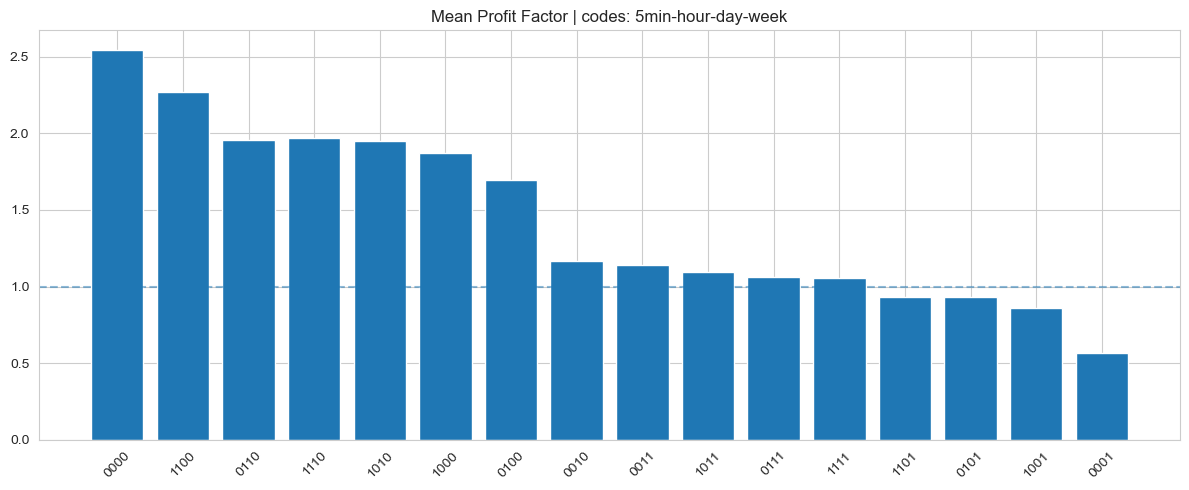


=== Top 10 Lookback Settings ===


,entry_lookback_h,total_configs,total_trades,win_rate_pct,agg_profit_factor,mean_EV_row,Composite_Z,Adjusted_Z
2,4,50175360.0,1.038468e+11,10.947,1.809,1.809,0.809,8.915
1,1,50175360.0,1.499769e+11,10.927,1.801,1.801,0.801,8.956
3,8,50175360.0,9.508059e+10,10.489,1.718,1.718,0.718,7.882
4,12,50175360.0,9.554441e+10,9.986,1.614,1.614,0.614,6.747
0,0,48556800.0,8.525396e+11,9.932,1.603,1.603,0.603,7.193
5,16,50175360.0,9.774706e+10,9.357,1.485,1.485,0.485,5.331
6,20,50175360.0,1.015919e+11,8.975,1.405,1.405,0.405,4.454
7,24,50175360.0,1.044786e+11,8.823,1.375,1.375,0.375,4.128
8,28,50175360.0,1.065710e+11,8.379,1.288,1.288,0.288,3.175
15,168,50175360.0,1.519300e+11,8.410,1.274,1.274,0.274,3.063



=== Top 10 Lookback x MA Combo (respecting MIN_ROWS_DOLLAR) ===


,entry_lookback_h,ma_combo,total_trades,agg_profit_factor,win_rate_pct,Composite_Z,Adjusted_Z
16,1,0000,2.033523e+10,3.608,19.309,0.504,5.192
24,1,1000,1.729416e+10,3.320,18.167,0.422,4.315
0,0,0000,8.656716e+10,3.003,17.091,0.342,3.744
20,1,0100,1.198625e+10,2.983,16.890,0.335,3.376
40,4,1000,1.196455e+10,2.848,16.204,0.299,3.017
32,4,0000,1.196470e+10,2.847,16.199,0.299,3.015
28,1,1100,1.080556e+10,2.773,15.956,0.283,2.838
14,0,1110,3.032286e+10,2.693,15.569,0.264,2.762
38,4,0110,5.120719e+09,2.670,15.428,0.258,2.502
46,4,1110,5.120567e+09,2.670,15.427,0.258,2.501


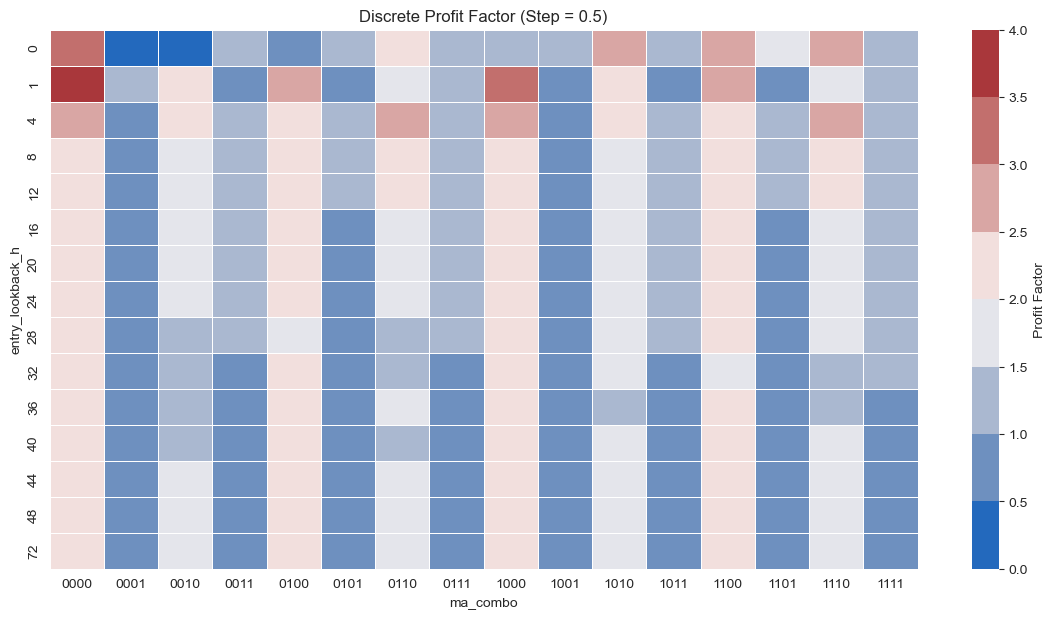

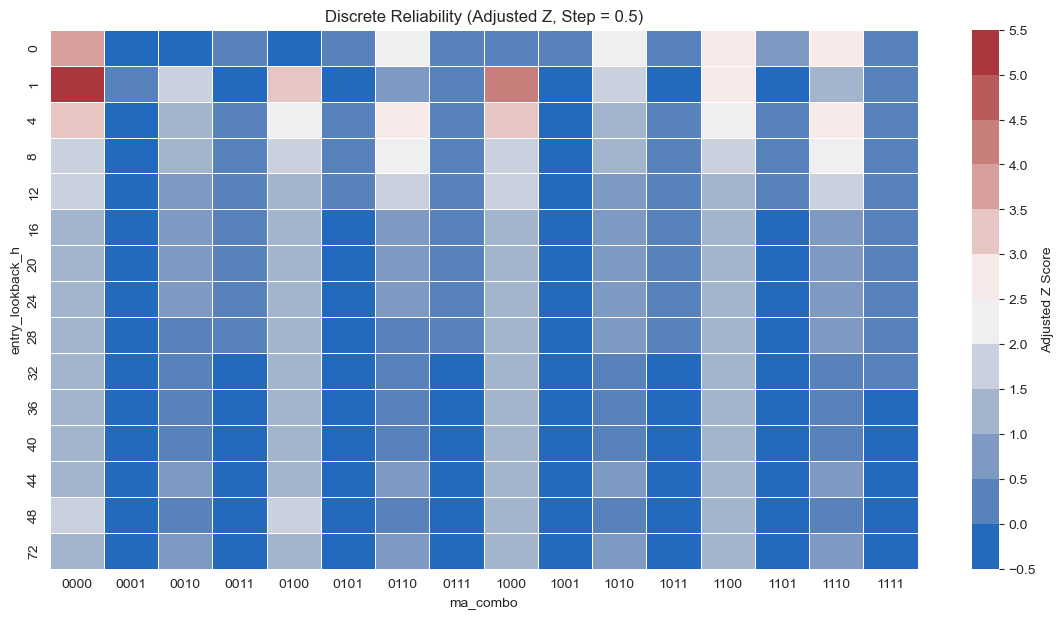


=== Top 10 Lookback x MA Combo (Sorted by Adjusted Z) ===


,entry_lookback_h,ma_combo,total_trades,agg_profit_factor,win_rate_pct,Composite_Z,Adjusted_Z
16,1,0000,2.033523e+10,3.608,19.309,0.504,5.192
24,1,1000,1.729416e+10,3.320,18.167,0.422,4.315
0,0,0000,8.656716e+10,3.003,17.091,0.342,3.744
20,1,0100,1.198625e+10,2.983,16.890,0.335,3.376
40,4,1000,1.196455e+10,2.848,16.204,0.299,3.017
32,4,0000,1.196470e+10,2.847,16.199,0.299,3.015
28,1,1100,1.080556e+10,2.773,15.956,0.283,2.838
14,0,1110,3.032286e+10,2.693,15.569,0.264,2.762
12,0,1100,5.096562e+10,2.590,15.754,0.251,2.682
38,4,0110,5.120719e+09,2.670,15.428,0.258,2.502



=== Top 10 Stop Loss / Take Profit Combinations (filtered) ===


,SL,TP,variations,avg_trades_per_run,mean_win_rate,mean_score_row,mean_EV_per_row,mean_EV_per_trade,total_win_dollars,total_loss_dollars,agg_profit_factor,total_trades_est,agg_EV_per_trade_est
842,100.0,12000.0,142560,3180.300568,10.963802,2.333391e+06,1226.620006,22.921102,3.714893e+11,4.224262e+10,8.794182,453383649.0,726.198847
841,100.0,11960.0,142560,3180.300568,10.977738,2.329425e+06,1223.915159,22.856230,3.709117e+11,4.223710e+10,8.781657,453383649.0,724.936995
840,100.0,11920.0,142560,3180.300568,10.990395,2.325066e+06,1221.045488,22.780775,3.702788e+11,4.223200e+10,8.767730,453383649.0,723.552296
839,100.0,11880.0,142560,3180.300568,11.003771,2.320974e+06,1218.251752,22.705262,3.696835e+11,4.222655e+10,8.754764,453383649.0,722.251349
838,100.0,11840.0,142560,3180.300568,11.018415,2.317151e+06,1215.598701,22.630978,3.691260e+11,4.222075e+10,8.742764,453383649.0,721.034516
837,100.0,11800.0,142560,3180.300568,11.032163,2.313147e+06,1212.827433,22.565712,3.685429e+11,4.221512e+10,8.730116,453383649.0,719.760827
836,100.0,11760.0,142560,3180.300568,11.045458,2.308994e+06,1209.991267,22.490596,3.679387e+11,4.220963e+10,8.716937,453383649.0,718.440299
835,100.0,11720.0,142560,3180.300568,11.059276,2.305096e+06,1207.206377,22.415162,3.673710e+11,4.220380e+10,8.704690,453383649.0,717.200947
834,100.0,11680.0,142560,3180.300568,11.073376,2.301191e+06,1204.443724,22.339971,3.668020e+11,4.219794e+10,8.692414,453383649.0,715.958811
833,100.0,11640.0,142560,3180.300568,11.086668,2.297272e+06,1201.574798,22.264071,3.662305e+11,4.219206e+10,8.680081,453383649.0,714.711275


In [28]:
# Section 3: Performance Analytics, Lookback Optimization & Visualizations

def get_inverse_combo(combo_str):
    # Swaps '1' to '0' and '0' to '1'
    return "".join(['1' if b == '0' else '0' for b in combo_str])

def draw_discrete_heatmap(data, mask, title, label, center_val=1.0, step=0.5, cmap_name="vlag"):
    """Helper to draw heatmap with discrete color buckets."""
    # Ensure data has range
    min_val = np.nanmin(data.values)
    max_val = np.nanmax(data.values)
    
    if min_val == max_val:
        # expand range slightly to allow color gradient
        min_val -= 0.5
        max_val += 0.5
    
    bounds = np.arange(floor(min_val / step) * step, ceil(max_val / step) * step + step, step)
    
    # Discrete colormap
    cmap = plt.get_cmap(cmap_name, len(bounds) - 1)
    norm = mcolors.BoundaryNorm(bounds, cmap.N)
    
    plt.figure(figsize=(14, 7))
    sns.heatmap(
        data, 
        mask=mask, 
        cmap=cmap, 
        norm=norm,
        linewidths=.5,
        cbar_kws={'label': label, 'ticks': bounds},
        annot=False
    )
    plt.title(title)
    plt.show()

# --- load aggregated summaries if not already in memory ---
try:
    df_ma
except NameError:
    p_path = RUN_BASE_DIR / "ma_summary.parquet"
    if p_path.exists():
        df_ma = pd.read_parquet(p_path)
    else:
        raise RuntimeError("ma_summary.parquet not found. Run the stream function with force_rebuild=True.")

try:
    df_lb_ma
except NameError:
    p_path = RUN_BASE_DIR / "lb_ma_summary.parquet"
    df_lb_ma = pd.read_parquet(p_path) if p_path.exists() else pd.DataFrame()

# helpers
def human_format(num, precision=2):
    if pd.isna(num):
        return ""
    try:
        n = float(num)
    except Exception:
        return str(num)
    absn = abs(n)
    if absn < 1_000:
        return f"{n:,.{precision}f}" if (absn < 100 and precision>0) else f"{n:,.0f}"
    for unit, div in [('Q', 10**15), ('T', 10**12), ('B', 10**9), ('M', 10**6), ('k', 10**3)]:
        if absn >= div:
            return f"{n/div:.{precision}f}{unit}"
    return f"{n:,.0f}"

# parameters for filtering / display
SL_MIN, SL_MAX = 100, 800
TP_MIN, TP_MAX = 1000, 15000
MIN_ROWS_DOLLAR = 100

ma_lookup = agg_by_ma.set_index('ma_combo')['agg_profit_factor'].to_dict()

# Calculate what the PF would be if we used the INVERSE logic
agg_by_ma['inverse_combo'] = agg_by_ma['ma_combo'].apply(get_inverse_combo)
agg_by_ma['inverse_agg_pf'] = agg_by_ma['inverse_combo'].map(ma_lookup)

# Calculate the "Edge Delta" 
# Positive means original logic is better; Negative means Inverse is better
agg_by_ma['edge_delta'] = agg_by_ma['agg_profit_factor'] - agg_by_ma['inverse_agg_pf']

display_cols_with_inv = ['ma_combo', 'inverse_combo', 'agg_profit_factor', 'inverse_agg_pf', 'edge_delta', 'Adjusted_Z']
print("\n=== MA Logic vs. Inverse Logic Comparison ===")
display(agg_by_ma[display_cols_with_inv].sort_values('edge_delta', ascending=False).round(2))

# --- 3.1 MA Combo Performance Summary ---
all_combos = [''.join(bits) for bits in product('01', repeat=4)]
agg_by_ma = df_ma.set_index('ma_combo').reindex(all_combos).fillna(0).reset_index()

# --- FIX: Calculate missing column if it's not in the loaded parquet ---
if 'avg_trades_per_config' not in agg_by_ma.columns:
    # Avoid division by zero with a tiny epsilon
    agg_by_ma['avg_trades_per_config'] = agg_by_ma['total_trades_found'] / (agg_by_ma['configs_tested'] + 1e-9)

if 'Composite_Z' not in agg_by_ma.columns:
    # Example proxy: Composite_Z = (PF - 1) * WinRate
    agg_by_ma['Composite_Z'] = (agg_by_ma['agg_profit_factor'] - 1) * (agg_by_ma['win_rate_pct'] / 100)

agg_by_ma['Adjusted_Z'] = agg_by_ma['Composite_Z'] * np.log10(agg_by_ma['total_trades_found'] + 1)

# Add it to your display columns
display_cols = ['ma_combo', 'configs_fmt', 'trades_fmt', 'agg_profit_factor', 'Adjusted_Z', 'mean_EV_row']

# Add readable formatting
agg_by_ma['configs_fmt'] = agg_by_ma['configs_tested'].apply(human_format)
agg_by_ma['trades_fmt'] = agg_by_ma['total_trades_found'].apply(human_format)
agg_by_ma = agg_by_ma.sort_values('Adjusted_Z', ascending=False).reset_index(drop=True)

print("\n=== MA Combo Performance Summary ===")
display_cols = ['ma_combo', 'trades_fmt', 'win_rate_pct', 'agg_profit_factor', 'Adjusted_Z', 'mean_EV_row']
display(agg_by_ma[display_cols].round(2))

# Bar chart - plot the sorted combos (kept exactly as you had it)
plt.figure(figsize=(12,5))
plt.bar(agg_by_ma['ma_combo'], agg_by_ma['agg_profit_factor'])
plt.axhline(1.0, linestyle='--', alpha=0.5)
plt.title('Mean Profit Factor | codes: 5min-hour-day-week')
plt.xticks(rotation=45)
try:
    plt.tight_layout()
except Exception as e:
    print("tight_layout failed — continuing (font/render issue):", e)

try:
    plt.show()
except Exception as e:
    print("plt.show() failed — continuing (non-fatal):", e)

# --- 3.2 Lookback Optimization Analysis (now includes ma_combo & seaborn heatmap) ---
if not df_lb_ma.empty:
    # ensure expected columns numeric where appropriate
    for col in ['entry_lookback_h','configs_tested','total_trades_found','agg_profit_factor','mean_EV_row','win_rate_pct']:
        if col in df_lb_ma.columns:
            df_lb_ma[col] = pd.to_numeric(df_lb_ma[col], errors='coerce')

    # drop rows missing the two keys we need
    df_lb_ma = df_lb_ma.dropna(subset=['entry_lookback_h','ma_combo'])

    # 1) overall aggregated by lookback (same as before)
    lb_overall = df_lb_ma.groupby('entry_lookback_h').agg(
        total_configs=('configs_tested', 'sum'),
        total_trades=('total_trades_found', 'sum'),
        win_rate_pct=('win_rate_pct', 'mean') if 'win_rate_pct' in df_lb_ma.columns else ('configs_tested','mean'),
        agg_profit_factor=('agg_profit_factor', 'mean'),
        mean_EV_row=('mean_EV_row', 'mean') if 'mean_EV_row' in df_lb_ma.columns else ('agg_profit_factor','mean')
    ).reset_index()

    lb_overall['Composite_Z'] = (lb_overall['agg_profit_factor'] - 1)
    lb_overall['Adjusted_Z'] = lb_overall['Composite_Z'] * np.log10(lb_overall['total_trades'] + 1)

    # apply MIN_ROWS_DOLLAR threshold for the Top-10 display (same logic as requested)
    lb_overall_filtered = lb_overall[lb_overall['total_trades'] >= MIN_ROWS_DOLLAR].copy()

    print("\n=== Top 10 Lookback Settings ===")
    if lb_overall_filtered.empty:
        print(f"No lookback rows meet MIN_ROWS_DOLLAR={MIN_ROWS_DOLLAR}. Falling back to full lb_overall.")
        display(lb_overall.sort_values('agg_profit_factor', ascending=False).head(10).round(3))
    else:
        display(lb_overall_filtered.sort_values('agg_profit_factor', ascending=False).head(10).round(3))

    # 2) breakdown by (entry_lookback_h, ma_combo) for heatmap + per-combo insights
    lb_by_combo = df_lb_ma.groupby(['entry_lookback_h','ma_combo']).agg(
        total_trades=('total_trades_found','sum'),
        agg_profit_factor=('agg_profit_factor','mean'),
        win_rate_pct=('win_rate_pct','mean') if 'win_rate_pct' in df_lb_ma.columns else ('total_trades_found','mean')
    ).reset_index()

    # Calculate Adjusted Z for the heatmap
    lb_by_combo['Composite_Z'] = (lb_by_combo['agg_profit_factor'] - 1) * (lb_by_combo['win_rate_pct'] / 100)
    lb_by_combo['Adjusted_Z'] = lb_by_combo['Composite_Z'] * np.log10(lb_by_combo['total_trades'] + 1)

    # also show Top 10 (entry_lookback_h, ma_combo) combinations by agg_profit_factor (respect MIN_ROWS_DOLLAR)
    lb_by_combo_top = lb_by_combo[lb_by_combo['total_trades'] >= MIN_ROWS_DOLLAR].sort_values('agg_profit_factor', ascending=False).head(10)
    if not lb_by_combo_top.empty:
        print("\n=== Top 10 Lookback x MA Combo (respecting MIN_ROWS_DOLLAR) ===")
        display(lb_by_combo_top.round(3))
    else:
        print(f"\nNo Lookback x MA Combo rows meet MIN_ROWS_DOLLAR={MIN_ROWS_DOLLAR} to show Top-10 by combo.")

    # 3) Seaborn heatmap: index=entry_lookback_h, columns=ma_combo, value=agg_profit_factor
    pivot_pf = lb_by_combo.pivot(
        index='entry_lookback_h',
        columns='ma_combo',
        values='agg_profit_factor'
    )

    pivot_az = lb_by_combo.pivot(
        index='entry_lookback_h',
        columns='ma_combo',
        values='Adjusted_Z'
    )

    pivot_count = lb_by_combo.pivot(
        index='entry_lookback_h',
        columns='ma_combo',
        values='total_trades'
    )

    # mask low-sample cells
    mask_low = (pivot_count < MIN_ROWS_DOLLAR) | pivot_pf.isna()

    # limit lookback range
    LIMIT_H = 75
    pivot_pf = pivot_pf.loc[:LIMIT_H]
    pivot_az = pivot_az.loc[:LIMIT_H]
    mask_low = mask_low.loc[:LIMIT_H]

    # Discrete Profit Factor heatmap
    draw_discrete_heatmap(
        pivot_pf,
        mask_low,
        title="Discrete Profit Factor (Step = 0.5)",
        label="Profit Factor",
        step=0.5,
        cmap_name="vlag"
    )

    # Discrete Adjusted Z heatmap
    draw_discrete_heatmap(
        pivot_az,
        mask_low,
        title="Discrete Reliability (Adjusted Z, Step = 0.5)",
        label="Adjusted Z Score",
        step=0.5,
        cmap_name="vlag"
    )

    print("\n=== Top 10 Lookback x MA Combo (Sorted by Adjusted Z) ===")
    display(lb_by_combo[lb_by_combo['total_trades'] >= MIN_ROWS_DOLLAR].sort_values('Adjusted_Z', ascending=False).head(10).round(3))

else:
    print("lb_ma summary is empty — no lookback analysis to show.")

# --- 3.3 Stop Loss / Take Profit Ranking (filtered display; unchanged) ---
print("\n=== Top 10 Stop Loss / Take Profit Combinations (filtered) ===")
if 'sltp_summary' in globals() and not sltp_summary.empty:
    # ensure numeric SL/TP
    sltp_summary[['SL','TP']] = sltp_summary[['SL','TP']].apply(pd.to_numeric, errors='coerce')
    sltp_filtered = sltp_summary[
        (sltp_summary['SL'] >= SL_MIN) & (sltp_summary['SL'] <= SL_MAX) &
        (sltp_summary['TP'] >= TP_MIN) & (sltp_summary['TP'] <= TP_MAX)
    ].copy()

    if sltp_filtered.empty:
        print(f"No SL/TP rows match SL in [{SL_MIN},{SL_MAX}] & TP in [{TP_MIN},{TP_MAX}]. Showing top overall instead.")
        display(sltp_summary.sort_values('agg_profit_factor', ascending=False).head(10))
    else:
        display(sltp_filtered.sort_values('agg_profit_factor', ascending=False).head(10))
else:
    print("sltp_summary not found or empty.")

In [29]:
# Compare the 'Best' vs the 'Most Filtered'
comparison_combos = ['0000', '1111']
quality_check = agg_by_ma[agg_by_ma['ma_combo'].isin(comparison_combos)].copy()

# Calculate 'Quality' as Profit per Trade (EV)
quality_check['EV_per_trade'] = quality_check['mean_EV_row'] 

print("=== Quality Comparison: Raw (0000) vs Over-Filtered (1111) ===")
display(quality_check[['ma_combo', 'total_trades_found', 'agg_profit_factor', 'win_rate_pct', 'mean_EV_row']])

=== Quality Comparison: Raw (0000) vs Over-Filtered (1111) ===


,ma_combo,total_trades_found,agg_profit_factor,win_rate_pct,mean_EV_row
0,0000,2.510306e+11,2.543684,14.876708,622.64574
11,1111,9.085771e+10,1.055935,7.009068,466.77241


In [ ]:
# Adjusted_Z=Composite_Z×log10(total\_pos)Adjusted\_Z = Composite\_Z \times \log_{10}(\text{total\_pos})

In [ ]:
# DIAGNOSTICS: inspect df_lb_ma shape + distribution and look for identical totals
print("df_lb_ma.shape:", df_lb_ma.shape)
print("columns:", df_lb_ma.columns.tolist())

# head samples
display(df_lb_ma.head(20))

# per-lookback aggregated info (shows sum/count/unique count_rows per lookback)
g = df_lb_ma.groupby('entry_lookback_h')['count_rows'].agg(['sum','count','mean','nunique']).reset_index()
print("\nPer-lookback count_rows summary:")
display(g.sort_values('entry_lookback_h').style.format({
    'sum': '{:,.0f}', 'count':'{:,.0f}', 'mean':'{:,.0f}', 'nunique':'{:,.0f}'
}))

# Are the 'sum' values identical across many lookbacks?
dups = g[g['sum'] == g['sum'].mode()[0]]
print(f"\nNumber of lookbacks with the modal sum ({int(g['sum'].mode()[0])}): {len(dups)}")
display(dups)

# pivot table: are the same count_rows repeated for each ma_combo across lookbacks?
pivot = df_lb_ma.pivot_table(index='ma_combo', columns='entry_lookback_h', values='count_rows', aggfunc='sum', fill_value=0)
print("\nPivot sample (ma_combo rows × lookback cols):")
display(pivot.head(10))

# If you want to inspect actual parquet files to see if file contents duplicate:
from pathlib import Path
base = RUN_BASE_DIR
files = sorted([p for p in base.rglob("BTC_SLTP_optimization_*.parquet") if "configs" not in p.parts])
print(f"\nFound {len(files)} parquet files; showing per-file lookback distribution (file, sum count_rows):")
for p in files[:20]:
    try:
        import pyarrow.parquet as pq
        tbl = pq.read_table(str(p), columns=[c for c in ['entry_lookback_h','win_pos','all_pos'] if c in pq.read_schema(str(p)).names])
        pdf = tbl.to_pandas()
        if 'entry_lookback_h' in pdf:
            counts = pdf['entry_lookback_h'].value_counts().sort_index().to_dict()
            print(p.name, counts)
    except Exception as e:
        print("skip", p.name, "->", e)

In [ ]:
# 1) Check unique values per parquet file (fast sample)
from collections import Counter
from pathlib import Path
import pyarrow.parquet as pq

base = RUN_BASE_DIR
files = sorted([p for p in base.rglob("BTC_SLTP_optimization_*.parquet") if "configs" not in p.parts])

summary = []
for p in files[:60]:   # sample first 60 files to keep it quick
    try:
        tbl = pq.read_table(str(p), columns=[c for c in ['entry_lookback_h','use_ma_5min','use_ma_hour','use_ma_day','use_ma_week'] if c in pq.read_schema(str(p)).names])
        pdf = tbl.to_pandas()
        lbs = tuple(sorted(pdf['entry_lookback_h'].unique())) if 'entry_lookback_h' in pdf else ('<missing>',)
        mas = tuple(int(bool(x)) for x in (pdf.get('use_ma_5min', pd.Series([False])).iloc[0],
                                           pdf.get('use_ma_hour', pd.Series([False])).iloc[0],
                                           pdf.get('use_ma_day', pd.Series([False])).iloc[0],
                                           pdf.get('use_ma_week', pd.Series([False])).iloc[0]))
        summary.append((p.parent.name, p.name, lbs, mas, len(pdf)))
    except Exception as e:
        summary.append((p.parent.name, p.name, ('<err>',), ('<err>',), 0))

from pprint import pprint
pprint(summary[:20])

In [ ]:
# 2) Are per-lookback sums identical?
g = df_lb_ma.groupby('entry_lookback_h')['count_rows'].agg(['sum','nunique','mean']).reset_index().sort_values('entry_lookback_h')
display(g)
# 3) Are count_rows identical across ma_combo for a single lookback?
sample_lb = g['entry_lookback_h'].iloc[0]   # pick first
print("sample lookback:", sample_lb)
display(df_lb_ma[df_lb_ma['entry_lookback_h']==sample_lb][['ma_combo','count_rows']])

In [ ]:
# StopLoss vs TakeProfit Risk Analysis: Tables & Plots
# (Powered by the memory-safe streaming sltp_summary)
# =============================================================================

# Map the streamed output to 'summary' for the display logic
summary = sltp_summary.copy()
top_n = 10

if summary.empty:
    print("Summary is empty. No plots or tables to generate.")
else:
    # ---- 1) Prepare display columns & info text ----
    # Note: 'median_win_rate' is excluded because medians cannot be easily 
    # calculated in a low-memory streaming pass (requires keeping all rows in memory).
    desired_display = [
        'SL','TP','variations','avg_trades_per_run',
        'mean_win_rate', 'mean_score_row_readable','mean_score_row',
        'mean_EV_per_row', 'agg_EV_per_trade_est','expectancy',
        'stability_score','agg_profit_factor','composite_z','total_trades_est'
    ]
    display_cols = [c for c in desired_display if c in summary.columns]

    print("\nNOTE: 'variations' is the number of optimizer rows/config variations that share the same SL and TP.")
    print("The 'mean_score_row' is the simple unweighted mean of your optimizer 'score' across those variations.")
    print("The economic metric 'agg_profit_factor' is computed as sum(win $) / sum(loss $) across those variations (dollar-weighted).")
    print("Rounding: mean win_rate, mean_EV_per_row and agg_EV_per_trade_est are shown with 2 decimals.\n")

    # ---- 2) Safe top lists and display ----
    def safe_head_sort(df, by_col, topn=top_n, ascending=False):
        if by_col not in df.columns:
            print(f"[warn] cannot sort by {by_col} (missing)")
            return pd.DataFrame()
        return df.sort_values(by_col, ascending=ascending)[display_cols].head(topn)

    print("Top by dollar-weighted profit factor (agg_profit_factor):")
    display(safe_head_sort(summary, 'agg_profit_factor', topn=top_n))

    print("\nTop by EV per trade estimate (agg_EV_per_trade_est):")
    display(safe_head_sort(summary, 'agg_EV_per_trade_est', topn=top_n))

    print("\nTop by stability_score (weights win_rate):")
    display(safe_head_sort(summary, 'stability_score', topn=top_n))

    print("\nTop by composite_z (zscaled EV + zscaled winrate):")
    display(safe_head_sort(summary, 'composite_z', topn=top_n))

    # ---- 3) Optional heatmap ----
    try:
        pivot = summary.pivot(index='TP', columns='SL', values='agg_EV_per_trade_est')
        if isinstance(pivot, pd.DataFrame) and pivot.size > 0:
            plt.figure(figsize=(10,6))
            # Convert index and columns to numeric to ensure proper sorting in the heatmap
            pivot.index = pd.to_numeric(pivot.index)
            pivot.columns = pd.to_numeric(pivot.columns)
            pivot = pivot.sort_index(ascending=True).sort_index(axis=1, ascending=True)

            plt.imshow(pivot.fillna(0.0), aspect='auto', origin='lower', cmap='RdYlGn')
            plt.colorbar(label='agg_EV_per_trade_est')
            plt.title('Heatmap: agg_EV_per_trade_est (TP rows × SL cols)')
            plt.xlabel('SL')
            plt.ylabel('TP')
            
            # Formatting ticks
            nx = max(1, int(pivot.shape[1] / 8))
            ny = max(1, int(pivot.shape[0] / 8))
            plt.xticks(np.arange(0, pivot.shape[1], nx), pivot.columns[::nx], rotation=45)
            plt.yticks(np.arange(0, pivot.shape[0], ny), pivot.index[::ny])
            plt.show()
        else:
            print("[info] pivot is empty — skipping heatmap.")
    except Exception as e:
        print("[warn] heatmap generation failed:", e)

    # ---- 4) Final top summary head ----
    summary = summary.sort_values('composite_z', ascending=False).reset_index(drop=True)
    print("\nDone. Top summary head:")
    display(summary[display_cols].head(top_n))

In [ ]:
# ---- Champion Summary Text Report ----

ranking_metrics = {
    "Efficiency (Profit Factor)": "agg_profit_factor",
    "Cashflow (EV per Trade)": "agg_EV_per_trade_est",
    "Psychology (Stability)": "stability_score",
    "Robustness (Composite Z)": "composite_z"
}

print("="*60)
print("             TOP CONFIGURATION PER CATEGORY")
print("="*60)

for label, col in ranking_metrics.items():
    if col in summary.columns:
        # Get the top row for this specific metric
        top_row = summary.sort_values(col, ascending=False).iloc[0]
        
        print(f"\nRANKED BY: {label} ({col})")
        print(f"  SL / TP:         {int(top_row['SL'])} / {int(top_row['TP'])}")
        print(f"  Variations:      {int(top_row['rows'])}")
        print(f"  Avg Trades/Run:  {top_row['avg_trades_per_run']:.1f}")
        print("-" * 30)
        print(f"  Win Rate:        {top_row['mean_win_rate']:.3f}%")
        print(f"  Profit Factor:   {top_row['agg_profit_factor']:.3f}")
        print(f"  EV per Trade:    {top_row['agg_EV_per_trade_est']:.4f}")
        print(f"  Stability Score: {top_row['stability_score']:.4f}")
        print(f"  Composite Z:     {top_row['composite_z']:.4f}")
        print("." * 60)
    else:
        print(f"\n[!] Column {col} missing - skipping {label}")

print("\n" + "="*60)

In [ ]:
"""
STRATEGY INSIGHT SUMMARY - BTC 5M SWING
---------------------------------------
TARGETED RANGE: SL 100-800 | TP 100-2000
OPTIMAL CONFIG: SL 101 | TP 551 (Risk-Reward 1:5.4)

METRICS:
- Expected Win Rate: ~27-28% 
- Frequency: ~7.8 trades/month (Based on 2017-2025 data)
- Expectancy: +$73.73 per trade (before slippage)
- Time Horizon: 240 hours (10 days) max hold

ROBUSTNESS NOTE:
The 101 SL is a stable 'Plateau' (3/3 profitable neighbors). 
Avoid SL 300+ as it creates 'Spikes' that are mathematically 
fragile and result in negative scores when neighbors are tested.

FILTERS USED:
1. Session Filter: 06:00 - 16:00 (High Liquidity) 2pm to 12am midnight Malaysia time
2. Trend Filter: Close > MA_5min AND Close > MA_hour
3. Breakout Strength: 72h Lookback (Trend following)
4. NO STOCHASTIC: Pure Price Action/Breakout focus
"""

In [ ]:


def visualize_5m_strategy(positions_df, df_5m_local,
                          ma_lines=('MA_5min', 'MA_hour', 'MA_day'),
                          height=700):
    """
    Optimized for 5m BTC Strategy.
    positions_df: The 'buy_df' containing results and rolling metrics.
    df_5m_local: The full 5m OHLC dataframe.
    """

    # 1. Downsample background price
    df_bg = df_5m_local.set_index('time').resample('1H').agg(
        {'close': 'last'}).dropna().reset_index()

    fig = go.Figure()

    # --- Trace 1: Background Price ---
    fig.add_trace(go.Scatter(
        x=df_bg['time'], y=df_bg['close'],
        mode='lines', name='Price (1H)',
        line=dict(color='rgba(100, 100, 100, 0.3)', width=1),
        hoverinfo='skip'
    ))

    # --- Trace 2: Moving Averages ---
    colors = {'MA_5min': 'cyan', 'MA_hour': 'orange', 'MA_day': 'red'}
    for ma in ma_lines:
        if ma in df_5m_local.columns:
            ma_resampled = df_5m_local.set_index('time')[ma].resample('1H').last().reset_index()
            fig.add_trace(go.Scatter(
                x=ma_resampled['time'], y=ma_resampled[ma],
                mode='lines', name=ma,
                line=dict(width=1, dash='dot', color=colors.get(ma, 'gray')),
                opacity=0.5
            ))

    # --- Trace 3: Position Markers ---
    pos = positions_df.copy()
    pos['Result_Label'] = pos['Result'].map({
        1: 'WIN (TP 551)', 
        0: 'LOSS (SL 101)', 
        2: 'BE'
    })

    # Add hover text
    hover_text = [
        f"Time: {t}<br>Price: {c}<br>Result: {r}<br>WinRate: {wr:.1f}%"
        for t, c, r, wr in zip(
            pos['time'], pos['close'], pos['Result_Label'], 
            pos.get('win_rate_1y', np.zeros(len(pos)))
        )
    ]

    fig.add_trace(go.Scatter(
        x=pos['time'],
        y=pos['close'],
        mode='markers',
        name='Positions',
        marker=dict(
            size=8,
            symbol='diamond',
            color=pos['Result'],
            colorscale=[[0, 'red'], [0.5, 'yellow'], [1, 'green']],
            line=dict(width=1, color='white')
        ),
        text=hover_text,
        hoverinfo='text'
    ))

    fig.update_layout(
        title="BTC 5M: SL 101 | TP 551",
        template="plotly_dark",
        height=height,
        xaxis_rangeslider_visible=False
    )

    pio.renderers.default = "browser"
    fig.show()
    return fig